# Definición del umbral operativo de lluvia fuerte

Esta notebook construye, desde cero, el umbral operativo de "lluvia fuerte" que se usará para etiquetar
el dataset de entrenamiento. Continúa el trabajo de `03-ground_truth_qc.ipynb`, que dejó 63 estaciones de
precipitación sub-horaria con calidad verificada (`estaciones_finales-despues_de_qc.txt`).

Estructura:
1. Construcción de la serie horaria
2. Definición de hora húmeda
3. Percentil operativo por estación
4. Chequeo de sensibilidad de la ventana de entrenamiento


## 1. Construcción de la serie horaria

Se agrega el registro sub-horario de cada estación a resolución horaria mediante una ventana deslizante
de 60 minutos (`.rolling('60min').sum()`), no por hora de reloj. Esto captura la intensidad real de un
evento aunque empiece a mitad de una hora calendario, en vez de partirlo artificialmente en dos horas más
débiles.

In [18]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

from numpy.random import default_rng
rng = default_rng(42)

RUTA_BASE = r'..\..\data\rainfall_subhourly'

with open('estaciones_finales-despues_de_qc.txt') as f:
    codigos_finales = f.read().splitlines()

print(f"{len(codigos_finales)} estaciones cargadas")

63 estaciones cargadas


In [4]:
def cargar_datos_estacion(codigo, ruta_base=RUTA_BASE):
    """Carga el CSV crudo (registros sub-horarios) de una estación, sin duplicados exactos."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    df = df.drop_duplicates(subset=['fechaobservacion', 'valorobservado'])
    return df


def serie_horaria(codigo, ruta_base=RUTA_BASE):
    """Agrega registros sub-horarios a precipitación horaria (ventana deslizante de 60 min)."""
    df = cargar_datos_estacion(codigo, ruta_base)
    df = df.set_index('fechaobservacion').sort_index()
    return df['valorobservado'].rolling('60min').sum()

In [5]:
# Prueba con la primera estación de la lista, solo para confirmar que la mecánica funciona
codigo_ejemplo = codigos_finales[0]
prueba = serie_horaria(codigo_ejemplo)

print(f"Serie horaria de {codigo_ejemplo}: {len(prueba)} registros")
prueba.describe()

Serie horaria de 2120000101: 323320 registros


count    323320.000000
mean          0.054764
std           0.433658
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          14.200000
Name: valorobservado, dtype: float64

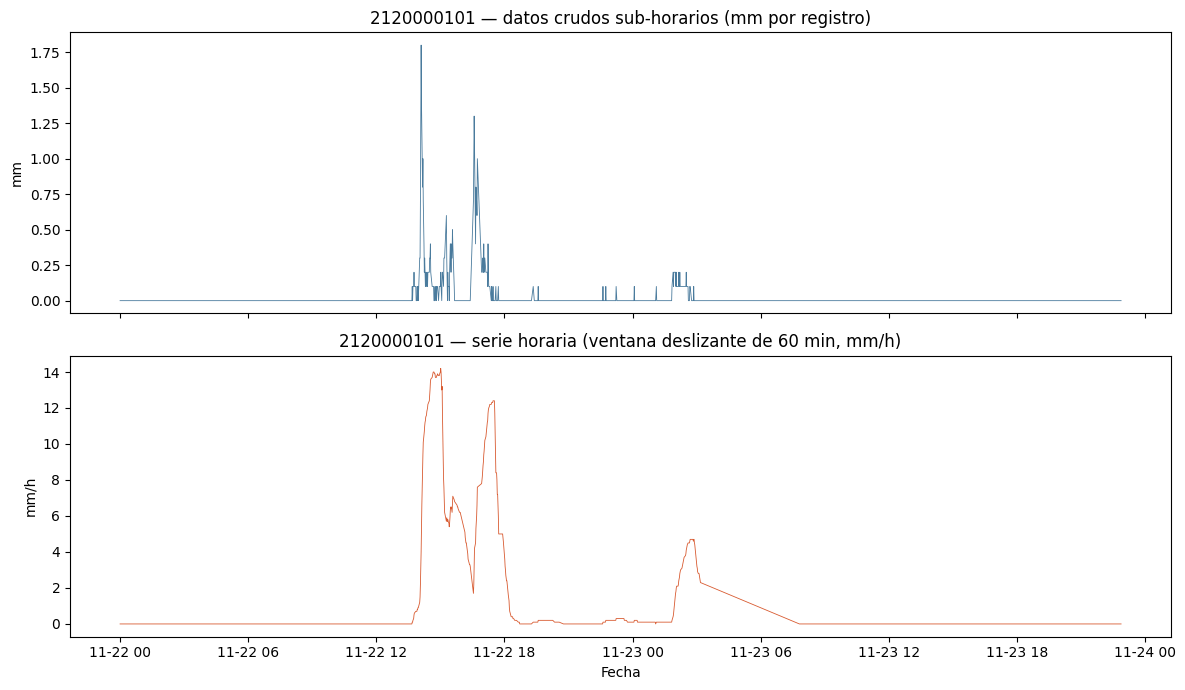

In [6]:
# Inspección visual: datos crudos sub-horarios vs. serie horaria agregada, sobre una ventana corta
# (un mes completo no deja distinguir la forma de la curva; una ventana de 2-3 días sí)

df_crudo = cargar_datos_estacion(codigo_ejemplo)

ini_ventana = pd.Timestamp('2024-11-22')
fin_ventana = pd.Timestamp('2024-11-24')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

crudo_ventana = df_crudo[(df_crudo['fechaobservacion'] >= ini_ventana) & (df_crudo['fechaobservacion'] < fin_ventana)]
axes[0].plot(crudo_ventana['fechaobservacion'], crudo_ventana['valorobservado'], lw=0.6, color='#4A7B9D')
axes[0].set_title(f'{codigo_ejemplo} — datos crudos sub-horarios (mm por registro)')
axes[0].set_ylabel('mm')

horaria_ventana = prueba[(prueba.index >= ini_ventana) & (prueba.index < fin_ventana)]
axes[1].plot(horaria_ventana.index, horaria_ventana.values, lw=0.6, color='#D85A30')
axes[1].set_title(f'{codigo_ejemplo} — serie horaria (ventana deslizante de 60 min, mm/h)')
axes[1].set_ylabel('mm/h')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

In [7]:
# Ahora a las 63 estaciones completas
series_horarias = {}

for codigo in codigos_finales:
    series_horarias[codigo] = serie_horaria(codigo)

print(f"{len(series_horarias)} series horarias calculadas")
print(f"Total de registros: {sum(len(s) for s in series_horarias.values()):,}")

63 series horarias calculadas
Total de registros: 22,774,536


In [8]:
partes = []
for codigo, serie in series_horarias.items():
    parte = serie.rename('intensidad_mm_h').reset_index()
    parte['codigoestacion'] = codigo
    partes.append(parte)

df_horaria = pd.concat(partes, ignore_index=True)[['codigoestacion', 'fechaobservacion', 'intensidad_mm_h']]

print(f"df_horaria: {len(df_horaria):,} filas, {df_horaria['codigoestacion'].nunique()} estaciones")
df_horaria.describe()

df_horaria: 22,774,536 filas, 63 estaciones


,fechaobservacion,intensidad_mm_h
count,22774536,2.277454e+07
mean,2025-04-11 06:30:47.889909248,8.947521e-02
min,2024-01-01 09:07:00,0.000000e+00
25%,2024-12-10 02:10:00,0.000000e+00
50%,2025-05-05 10:15:00,0.000000e+00
75%,2025-10-01 14:23:00,0.000000e+00
max,2025-12-31 23:59:00,8.600000e+01
std,NaN,7.036011e-01


In [9]:
# Guardamos la serie horaria completa (sin filtrar aún por hora húmeda) — la usaremos en las secciones siguientes
df_horaria.to_parquet('df_horaria.parquet', index=False)

In [2]:
# Celda útil SOLO en caso de reseteo de notebook y df_horaria.parquet está ya calculado y cargado en disco
df_horaria = pd.read_parquet('df_horaria.parquet')         # Solo necesaria para no correr la sección 1
# df_horaria['hora_humeda'] = df_horaria['intensidad_mm_h'] >= 0.2   # Solo necesaria para no correr la sección 2

print(f"df_horaria cargado: {len(df_horaria):,} filas, {df_horaria['codigoestacion'].nunique()} estaciones")

df_horaria cargado: 22,774,536 filas, 63 estaciones


## 2. Definición de hora húmeda

Una hora se considera "húmeda" si su intensidad horaria (serie construida en la Sección 1) alcanza o supera 0.2 mm/h. Ese valor no es una elección de percentil: es el límite de detección instrumental más conservador entre los sensores presentes en las 63 estaciones finales — 61 estaciones resuelven a 0.1mm, 2 estaciones (`2120500135`, `0021205910`) resuelven a 0.2mm (ver `resolucion_decimal_estaciones.csv` de `03-ground_truth_qc.ipynb`). Usar un piso uniforme de 0.2 mm/h evita que la definición de "húmeda" varíe según qué instrumento tenga cada estación, aunque signifique perder algo de señal fina en las 61 estaciones con mejor resolución (horas entre 0.1 y 0.2 mm/h se tratan como secas para todas por igual).

Esta sección solo filtra qué horas entran al cálculo del percentil operativo (Sección 3) — no excluye nada del dataset final de etiquetado, que sí debe cubrir todas las horas, húmedas o no.

In [10]:
UMBRAL_HORA_HUMEDA = 0.2

df_horaria['hora_humeda'] = df_horaria['intensidad_mm_h'] >= UMBRAL_HORA_HUMEDA

n_total = len(df_horaria)
n_humedas = df_horaria['hora_humeda'].sum()

print(f"Horas totales: {n_total:,}")
print(f"Horas húmedas (≥{UMBRAL_HORA_HUMEDA} mm/h): {n_humedas:,} ({n_humedas/n_total*100:.2f}%)")

# Conteo de horas húmedas por estación — para confirmar que ninguna estación queda con muestra insuficiente
horas_humedas_por_estacion = df_horaria[df_horaria['hora_humeda']].groupby('codigoestacion').size().sort_values()
print(f"\nHoras húmedas por estación — mínimo: {horas_humedas_por_estacion.min()}, máximo: {horas_humedas_por_estacion.max()}")
horas_humedas_por_estacion.describe()

Horas totales: 22,774,536
Horas húmedas (≥0.2 mm/h): 1,413,820 (6.21%)

Horas húmedas por estación — mínimo: 847, máximo: 39880


count       63.000000
mean     22441.587302
std       9847.362458
min        847.000000
25%      16429.500000
50%      25524.000000
75%      28555.500000
max      39880.000000
dtype: float64

## 3. Confiabilidad del percentil por estación

Antes de calcular el P95 operativo de cada estación (Sección 4), hay que establecer cuántos datos hacen falta para que ese percentil sea confiable — no todas las 63 estaciones tienen la misma cantidad de horas húmedas ni la misma cobertura temporal dentro de 2024, el período de referencia.

Se establece un criterio de confiabilidad con dos condiciones, ambas derivadas empíricamente:

1. **Tamaño de muestra mínimo** (Sección 3.1): cuántas horas húmedas hacen falta para que el P95 estimado sea estadísticamente estable.
2. **Cobertura temporal mínima** (Sección 3.2): que esas horas húmedas no estén concentradas en una sola temporada del año, sino que reflejen la estacionalidad real.

### 3.1 Tamaño de muestra mínimo

El P95 de cada estación se calcula sobre su propia muestra de horas húmedas en 2024. Antes de aceptar ese número como confiable, hay que saber cuántas horas húmedas hacen falta para que la estimación sea estable — con muy pocos datos, el percentil calculado depende más de qué eventos particulares cayeron en la muestra que de la climatología real de la estación.

Esto se responde con **bootstrap**: en vez de asumir matemáticamente cómo se comportaría el P95 con menos datos, se simula directamente. Se toma la muestra completa de una estación con buena cobertura, y de ahí se extraen repetidamente submuestras más chicas al azar, de distintos tamaños. Para cada tamaño, se calcula el P95 sobre cientos de esas submuestras y se mide qué tan disperso resulta el conjunto de estimaciones (su coeficiente de variación, CV — la desviación estándar como % de la media). Un CV alto significa que el percentil estimado varía mucho según qué datos específicos caen en la muestra, y por lo tanto no es confiable con ese tamaño; un CV bajo indica que el número ya se estabiliza.

El corte de tamaño mínimo no puede calibrarse con una sola estación de referencia, porque la cantidad de datos necesaria para estabilizar un percentil depende de la forma de la distribución subyacente de cada estación (qué tan dispersos son sus valores extremos), no es una propiedad universal. Por eso se aplica un **muestreo estratificado**: se seleccionan varias estaciones con buena cobertura, agrupadas en tres estratos según su P95 (bajo, medio, alto), tomando estaciones de distinta cantidad de muestra dentro de cada estrato. El bootstrap se corre sobre las nueve, y el corte final se fija en el caso más exigente de las nueve — no en el promedio ni en el más favorable — para que el criterio sea válido para cualquier estación de la red, no solo para las que convergen rápido.

In [12]:
# Calculando horas humedas 2024 y sis percentiles por estación
horas_humedas_2024 = df_horaria[
    (df_horaria['fechaobservacion'].dt.year == 2024) & (df_horaria['hora_humeda'])
]

def percentiles_por_estacion(df, percentiles=[90, 95, 99]):
    filas = []
    for codigo, grupo in df.groupby('codigoestacion'):
        valores = grupo['intensidad_mm_h'].values
        fila = {'codigoestacion': codigo, 'n_horas_humedas': len(valores)}
        for p in percentiles:
            fila[f'p{p}'] = np.percentile(valores, p)
        filas.append(fila)
    return pd.DataFrame(filas).set_index('codigoestacion')

def meses_con_dato_2024(codigo):
    datos = horas_humedas_2024[horas_humedas_2024['codigoestacion'] == codigo]
    return datos['fechaobservacion'].dt.month.nunique()

percentiles_estacion_2024 = percentiles_por_estacion(horas_humedas_2024)

print(f"Horas húmedas 2024: {len(horas_humedas_2024):,}, {percentiles_estacion_2024.shape[0]} estaciones")

Horas húmedas 2024: 320,936, 63 estaciones


In [ ]:
# Candidatas al estratificado:
candidatas_estrato = percentiles_estacion_2024[
    (percentiles_estacion_2024['n_horas_humedas'] >= 2000) &
    (percentiles_estacion_2024.index.map(meses_con_dato_2024) >= 8)
].copy()

# Tres estratos por P95: bajo, medio, alto
candidatas_estrato['estrato_p95'] = pd.qcut(candidatas_estrato['p95'], q=3, labels=['bajo', 'medio', 'alto'])

# Tres estaciones por estrato: la de menor, mediana y mayor cobertura dentro del estrato —
# para que la muestra no dependa solo de estaciones con mucha abundancia de dato.
estaciones_seleccionadas = []
for estrato, grupo in candidatas_estrato.groupby('estrato_p95', observed=True):
    grupo_ordenado = grupo.sort_values('n_horas_humedas')
    seleccion = pd.concat([
        grupo_ordenado.iloc[[0]],
        grupo_ordenado.iloc[[len(grupo_ordenado)//2]],
        grupo_ordenado.iloc[[-1]],
    ]).drop_duplicates()
    estaciones_seleccionadas.append(seleccion.assign(estrato=estrato))

df_seleccion = pd.concat(estaciones_seleccionadas)
print(f"{len(df_seleccion)} estaciones seleccionadas para el bootstrap estratificado:\n")
df_seleccion[['p95', 'n_horas_humedas', 'estrato']].sort_values(['estrato', 'p95'])

9 estaciones seleccionadas para el bootstrap estratificado:



,p95,n_horas_humedas,estrato
codigoestacion,,,
2120000174,7.600,7282,alto
2120000133,8.300,8921,alto
0021202240,8.555,4990,alto
0021202230,2.600,3184,bajo
2120000122,4.500,7358,bajo
2120000106,4.800,5164,bajo
2120000125,5.120,3497,medio
2120000126,5.400,6343,medio
2120000171,6.200,8808,medio


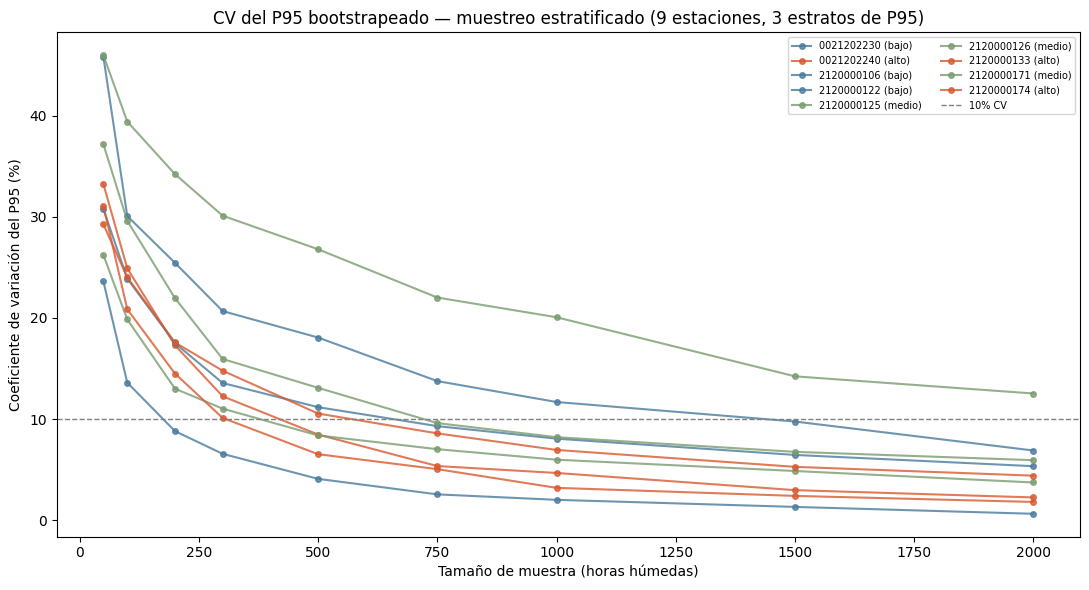

Primer tamaño de muestra donde el CV cae a <=10%, por estación:
codigoestacion
0021202230     200.0
2120000126     500.0
2120000133     500.0
0021202240     500.0
2120000171     750.0
2120000122     750.0
2120000174     750.0
2120000106    1500.0
2120000125       NaN
Name: n_muestra, dtype: float64

Corte de tamaño de muestra: n = 1500 horas húmedas en 2024


In [29]:
def bootstrap_p95(codigo, tamanos_muestra=[50, 100, 200, 300, 500, 750, 1000, 1500, 2000], n_repeticiones=500):
    valores = horas_humedas_2024[horas_humedas_2024['codigoestacion'] == codigo]['intensidad_mm_h'].values
    filas = []
    for n in tamanos_muestra:
        if n > len(valores):
            continue
        p95_muestreados = [np.percentile(rng.choice(valores, size=n, replace=False), 95) for _ in range(n_repeticiones)]
        filas.append({'codigo': codigo, 'estrato': df_seleccion.loc[codigo, 'estrato'],
                       'n_muestra': n, 'p95_cv_pct': np.std(p95_muestreados) / np.mean(p95_muestreados) * 100})
    return pd.DataFrame(filas)

resultado_estratificado = pd.concat([bootstrap_p95(codigo) for codigo in df_seleccion.index])

fig, ax = plt.subplots(figsize=(11, 6))
colores_estrato = {'bajo': '#4A7B9D', 'medio': '#7A9B6F', 'alto': '#D85A30'}
for codigo, grupo in resultado_estratificado.groupby('codigo'):
    estrato = grupo['estrato'].iloc[0]
    ax.plot(grupo['n_muestra'], grupo['p95_cv_pct'], marker='o', markersize=4,
            color=colores_estrato[estrato], alpha=0.8, label=f'{codigo} ({estrato})')

UMBRAL_CV = 10
ax.axhline(UMBRAL_CV, color='gray', ls='--', lw=1, label=f'{UMBRAL_CV}% CV')
ax.set_xlabel('Tamaño de muestra (horas húmedas)')
ax.set_ylabel('Coeficiente de variación del P95 (%)')
ax.set_title('CV del P95 bootstrapeado — muestreo estratificado (9 estaciones, 3 estratos de P95)')
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

cruces = resultado_estratificado[resultado_estratificado['p95_cv_pct'] <= UMBRAL_CV].groupby('codigo')['n_muestra'].min()
cruces = cruces.reindex(df_seleccion.index)
print(f"Primer tamaño de muestra donde el CV cae a <={UMBRAL_CV}%, por estación:")
print(cruces.sort_values())

N_MINIMO_HORAS = int(cruces.max())
print(f"\nCorte de tamaño de muestra: n = {N_MINIMO_HORAS} horas húmedas en 2024")

**Decisión: n ≥ 1500 horas húmedas en 2024.** Es el caso más exigente de las nueve estaciones evaluadas — determinado por la forma de su propia distribución, no por pertenecer al estrato de P95 más alto (el estrato bajo también incluye tanto el caso más rápido en converger como el más lento). El umbral de CV se fija en 10%, no en un valor más estricto, porque este criterio funciona como filtro binario (confiable / no confiable) para decidir qué estaciones usan su propio percentil, no como una estimación que requiera precisión fina.

### 3.2 Cobertura temporal mínima

El corte de horas húmedas podría, en principio, cumplirse con datos concentrados en pocos meses del año, sin reflejar la estacionalidad real. Se verifica que no sea el caso:

In [31]:
meses_de_confiables = pd.Series(
    {codigo: meses_con_dato_2024(codigo) for codigo in percentiles_estacion_2024[
        percentiles_estacion_2024['n_horas_humedas'] >= N_MINIMO_HORAS].index}
)

print(f"Meses con dato en 2024, entre las estaciones que cumplen n >= {N_MINIMO_HORAS}:")
print(meses_de_confiables.describe())
print(f"\nMínimo observado: {meses_de_confiables.min()} meses — ninguna estación queda con cobertura concentrada en pocos meses.")

Meses con dato en 2024, entre las estaciones que cumplen n >= 1500:
count    52.000000
mean     10.250000
std       1.218726
min       7.000000
25%      10.000000
50%      10.000000
75%      11.000000
max      12.000000
dtype: float64

Mínimo observado: 7 meses — ninguna estación queda con cobertura concentrada en pocos meses.


Todas las estaciones que superan el corte de tamaño de muestra tienen al menos 7 meses de cobertura en 2024 — el criterio de tamaño de muestra ya garantiza representatividad estacional por sí solo, sin necesidad de un segundo filtro independiente.

## 4. Percentil operativo por estación

El umbral operativo se calcula como un percentil empírico directo (sin ajustar una distribución paramétrica) sobre las horas húmedas de 2024 de cada estación, restringido a las estaciones que superan el criterio de confiabilidad de la Sección 3. Se calcula por estación, no de forma agrupada (pooled) ni por cluster geográfico, porque la Sabana de Bogotá tiene microclimas reales — dos estaciones cercanas pueden tener regímenes de lluvia genuinamente distintos por efecto orográfico y de convección local.

Se comparan tres candidatos (P90, P95, P99) antes de fijar uno, para decidir con el dato en mano cuál da un corte razonable de "lluvia fuerte" frente al rango que ofrece la literatura (aproximadamente 4 mm/h, umbral que la OMM asocia a lluvia fuerte, hasta ~10 mm/h, valor reportado por Casallas-García et al. (2023) para la Sabana) — ese rango sirve como referencia de plausibilidad, no como objetivo a alcanzar.

In [32]:
codigos_confiables = percentiles_estacion_2024[
    percentiles_estacion_2024['n_horas_humedas'] >= N_MINIMO_HORAS
].index.tolist()

percentiles_confiables = percentiles_estacion_2024.loc[codigos_confiables]

print(f"Percentil operativo calculado sobre {len(percentiles_confiables)} de {len(percentiles_estacion_2024)} estaciones "
      f"(las que superan el criterio de confiabilidad de la Sección 3)\n")
print("Estadística resumen de cada percentil candidato, a través de las estaciones confiables:\n")
print(percentiles_confiables[['p90', 'p95', 'p99']].describe())

percentiles_confiables.sort_values('p95', ascending=False)

Percentil operativo calculado sobre 52 de 63 estaciones (las que superan el criterio de confiabilidad de la Sección 3)

Estadística resumen de cada percentil candidato, a través de las estaciones confiables:

             p90        p95        p99
count  52.000000  52.000000  52.000000
mean    4.026923   6.406538  13.116231
std     1.159145   2.213439   5.497785
min     1.900000   2.600000   4.217000
25%     3.300000   4.875000   8.700000
50%     3.800000   5.950000  12.250000
75%     4.922500   7.791250  16.250000
max     7.500000  12.900000  30.300000


,n_horas_humedas,p90,p95,p99
codigoestacion,,,,
2120000140,8152,7.50,12.900,24.300
2120000103,5764,4.70,11.100,24.400
2120000138,6220,5.20,9.800,24.681
2120000099,5994,5.50,9.700,16.900
2120000135,7601,6.50,9.300,16.200
2120000170,7784,6.10,9.200,18.500
0021206890,7874,5.00,9.100,22.027
2120000139,5076,5.10,9.100,20.400
2120000118,7297,5.40,8.900,16.804


**Decisión: P95.** P90 da una mediana de 3.80 mm/h entre estaciones — por debajo del piso de 4 mm/h que la OMM asocia a lluvia fuerte, algo bajo para calificar como tal. P99 da una mediana de 12.25 mm/h, ya por encima del techo de 10 mm/h reportado por Casallas-García et al. (2023) para la Sabana, acercándose a valores que la literatura reserva para eventos torrenciales, no lluvia fuerte. P95 da una mediana de 5.95 mm/h, dentro del rango de literatura (4-10 mm/h) que sirve como referencia de plausibilidad — se fija como el umbral operativo.

El rango de P95 entre estaciones va de 2.6 a 12.9 mm/h — un factor de 5x, más contenido que el rango de 2.2 a 15.5 mm/h observado antes de aplicar el criterio de confiabilidad de la Sección 3, lo que sugiere que parte de esa dispersión original respondía a percentiles mal estimados por falta de muestra, no solo a variabilidad climática real entre estaciones.

### 4.1 Verificación: ¿el P95 bajo de algunas estaciones es señal real o artefacto del cálculo?

El rango de P95 entre estaciones va de 2.6 a 12.9 mm/h. Antes de aceptar esa dispersión como climatológicamente real, se verifica si el P95 bajo de ciertas estaciones podría deberse a un exceso de lluvia débil en su distribución (lo que arrastraría el percentil hacia abajo sin que refleje una diferencia real en la frecuencia de eventos intensos), en vez de a una menor ocurrencia genuina de lluvia fuerte.

Se comparan tres estaciones de P95 bajo contra estaciones de contraste con máximo histórico 2024 similar pero P95 más alto — si el P95 bajo fuera un artefacto de la forma de la distribución, la parte baja (horas de lluvia débil) debería verse distinta entre el par; si es una diferencia real en la frecuencia de eventos extremos, la parte baja debería ser comparable y la diferencia debería concentrarse en la cola.

In [33]:
# Elegimos 3 estaciones de umbral bajo (las de P95 más bajo entre las confiables) y, para cada una,
# buscamos una estación de contraste con máximo histórico similar en 2024 pero P95 más alto —
# misma lógica de la comparación de ayer, repetida para confirmar que el patrón se sostiene.

percentiles_confiables['max_lluvia_2024'] = [
    horas_humedas_2024[horas_humedas_2024['codigoestacion'] == c]['intensidad_mm_h'].max()
    for c in percentiles_confiables.index
]

candidatas_bajas = percentiles_confiables.sort_values('p95').head(3)
print("Estaciones de umbral bajo a investigar:")
print(candidatas_bajas[['p95', 'max_lluvia_2024']])

pares_comparacion = []
for codigo_bajo in candidatas_bajas.index:
    max_bajo = candidatas_bajas.loc[codigo_bajo, 'max_lluvia_2024']
    # Contraste: máximo histórico similar (+/- 3 mm/h), pero P95 claramente más alto
    candidatos_contraste = percentiles_confiables[
        (percentiles_confiables['max_lluvia_2024'].between(max_bajo - 3, max_bajo + 3)) &
        (percentiles_confiables['p95'] >= candidatas_bajas.loc[codigo_bajo, 'p95'] + 2) &
        (percentiles_confiables.index != codigo_bajo)
    ]
    if len(candidatos_contraste) > 0:
        codigo_alto = candidatos_contraste['p95'].idxmax()
        pares_comparacion.append((codigo_bajo, codigo_alto))
        print(f"\n{codigo_bajo} (P95={candidatas_bajas.loc[codigo_bajo, 'p95']:.2f}, max={max_bajo:.1f}) "
              f"vs. {codigo_alto} (P95={percentiles_confiables.loc[codigo_alto, 'p95']:.2f}, "
              f"max={percentiles_confiables.loc[codigo_alto, 'max_lluvia_2024']:.1f})")
    else:
        print(f"\n{codigo_bajo}: no se encontró contraste con máximo similar — se deja fuera de la comparación")

Estaciones de umbral bajo a investigar:
                p95  max_lluvia_2024
codigoestacion                      
0021202230      2.6              7.8
0021206810      3.1             13.2
0021202190      3.2             10.7

0021202230 (P95=2.60, max=7.8) vs. 2120000107 (P95=5.90, max=10.5)

0021206810 (P95=3.10, max=13.2) vs. 2120500201 (P95=7.40, max=15.1)

0021202190 (P95=3.20, max=10.7) vs. 2120000107 (P95=5.90, max=10.5)


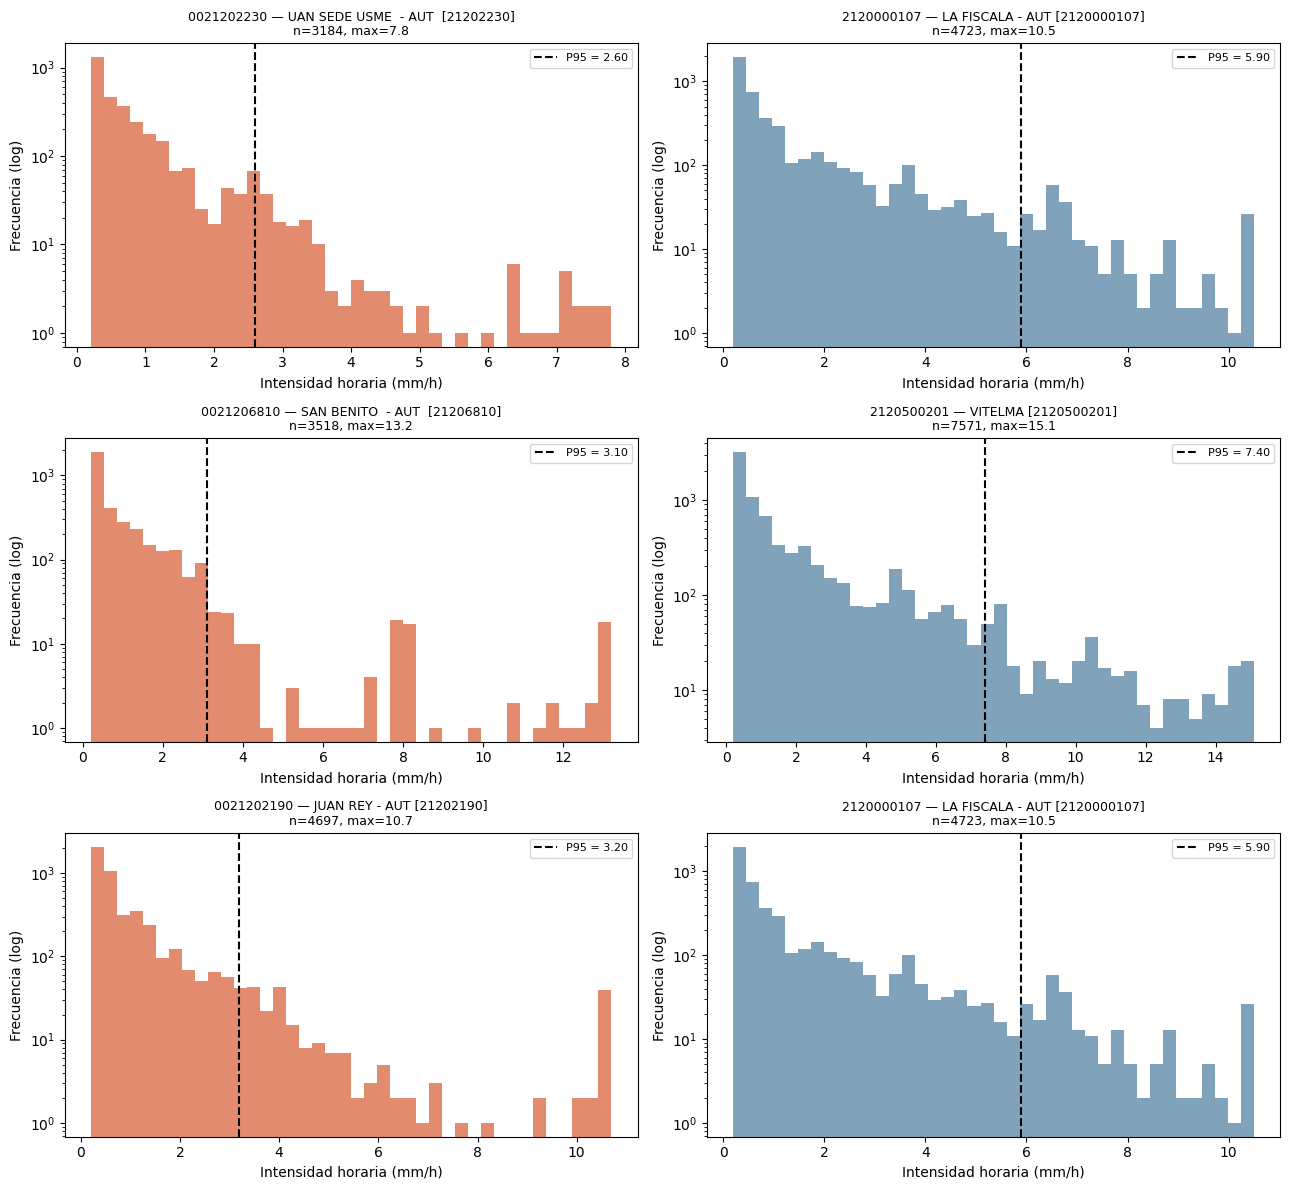


=== 0021202230 (bajo) vs 2120000107 (contraste) ===
  bajo (0021202230): mediana=0.50, %<=0.5mm/h=55.9%, %<=1.0mm/h=77.8%
  contraste (2120000107): mediana=0.60, %<=0.5mm/h=47.1%, %<=1.0mm/h=66.9%

=== 0021206810 (bajo) vs 2120500201 (contraste) ===
  bajo (0021206810): mediana=0.50, %<=0.5mm/h=53.7%, %<=1.0mm/h=71.0%
  contraste (2120500201): mediana=0.70, %<=0.5mm/h=41.6%, %<=1.0mm/h=58.7%

=== 0021202190 (bajo) vs 2120000107 (contraste) ===
  bajo (0021202190): mediana=0.50, %<=0.5mm/h=52.5%, %<=1.0mm/h=75.0%
  contraste (2120000107): mediana=0.60, %<=0.5mm/h=47.1%, %<=1.0mm/h=66.9%


In [35]:
metadatos = pd.read_csv('resumen_qc_66_estaciones_original.csv', dtype={'codigo': str}).set_index('codigo')

fig, axes = plt.subplots(3, 2, figsize=(13, 12))

for fila, (codigo_bajo, codigo_alto) in enumerate(pares_comparacion):
    for col, codigo in enumerate([codigo_bajo, codigo_alto]):
        valores = horas_humedas_2024[horas_humedas_2024['codigoestacion'] == codigo]['intensidad_mm_h'].values
        ax = axes[fila, col]
        color = '#D85A30' if col == 0 else '#4A7B9D'
        ax.hist(valores, bins=40, color=color, alpha=0.7)
        ax.axvline(np.percentile(valores, 95), color='black', ls='--', lw=1.5,
                   label=f'P95 = {np.percentile(valores, 95):.2f}')
        ax.set_title(f'{codigo} — {metadatos.loc[codigo, "nombre"]}\nn={len(valores)}, max={valores.max():.1f}', fontsize=9)
        ax.set_xlabel('Intensidad horaria (mm/h)')
        ax.set_ylabel('Frecuencia (log)')
        ax.legend(fontsize=8)
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Comparación numérica de la forma de cada par
for codigo_bajo, codigo_alto in pares_comparacion:
    print(f"\n=== {codigo_bajo} (bajo) vs {codigo_alto} (contraste) ===")
    for codigo, etiqueta in [(codigo_bajo, 'bajo'), (codigo_alto, 'contraste')]:
        valores = horas_humedas_2024[horas_humedas_2024['codigoestacion'] == codigo]['intensidad_mm_h'].values
        print(f"  {etiqueta} ({codigo}): mediana={np.median(valores):.2f}, "
              f"%<=0.5mm/h={np.mean(valores<=0.5)*100:.1f}%, "
              f"%<=1.0mm/h={np.mean(valores<=1.0)*100:.1f}%")

**Resultado:** en los tres pares, la parte baja de la distribución es comparable entre la estación de P95 bajo y su contraste — si acaso, la estación de P95 bajo tiene una fracción ligeramente *mayor* de horas de lluvia débil (53-56% ≤0.5 mm/h) que su contraste (41-47%), lo opuesto de lo que produciría un artefacto de cálculo que inflara falsamente el percentil bajo. La diferencia real está en la cola: las estaciones de P95 bajo tienen una frecuencia notablemente menor de eventos por encima de ~5-7 mm/h, visible en los histogramas como una cola que se corta antes.

Se concluye que la dispersión de P95 entre estaciones refleja diferencias reales en la frecuencia de eventos de lluvia intensa — consistente con la variabilidad orográfica y de microclima conocida dentro de la Sabana de Bogotá — y no un artefacto del método de cálculo.

### 4.2 Balance de clases

El umbral P95 por estación produce un desbalance de clases severo, como corresponde a un evento meteorológico raro: 0.24% de las horas quedan etiquetadas como "lluvia fuerte" (mediana por estación), con un rango de 0.16% a 0.32% entre estaciones. Esto confirma la necesidad de métricas de destreza apropiadas para eventos raros (CSI, FSS, POD, FAR — no accuracy simple) y de un diseño cuidadoso del muestreo de negativos en la construcción del dataset de entrenamiento.

In [36]:
umbral_por_estacion = percentiles_confiables['p95'].to_dict()

datos_2024_confiables = df_horaria[
    (df_horaria['fechaobservacion'].dt.year == 2024) &
    (df_horaria['codigoestacion'].isin(codigos_confiables))
].copy()
datos_2024_confiables['umbral_estacion'] = datos_2024_confiables['codigoestacion'].map(umbral_por_estacion)
datos_2024_confiables['lluvia_fuerte'] = datos_2024_confiables['intensidad_mm_h'] >= datos_2024_confiables['umbral_estacion']

balance_global = datos_2024_confiables['lluvia_fuerte'].value_counts(normalize=True) * 100
print("Balance de clases sobre todas las horas de 2024, estaciones confiables:")
print(balance_global)

balance_por_estacion = datos_2024_confiables.groupby('codigoestacion')['lluvia_fuerte'].mean() * 100
print(f"\n% de horas 'lluvia fuerte' por estación — min: {balance_por_estacion.min():.3f}%, "
      f"mediana: {balance_por_estacion.median():.3f}%, max: {balance_por_estacion.max():.3f}%")

Balance de clases sobre todas las horas de 2024, estaciones confiables:
lluvia_fuerte
False    99.759335
True      0.240665
Name: proportion, dtype: float64

% de horas 'lluvia fuerte' por estación — min: 0.161%, mediana: 0.244%, max: 0.321%


### Decisión: P95 empírico, piso de hora húmeda 0.2 mm/h, umbral por estación

**Umbral operativo final:** el P95 empírico de intensidad horaria, calculado por estación sobre las horas húmedas (≥0.2 mm/h) del período de referencia 2024, restringido a las estaciones que superan el criterio de confiabilidad de la Sección 3 (52 de 63).

**Por qué P95 y no P90 o P99:** P90 da una mediana de 3.80 mm/h entre estaciones — por debajo del piso de 4 mm/h que la OMM asocia a lluvia fuerte, demasiado bajo. P99 da una mediana de 12.25 mm/h, ya por encima del techo de 10 mm/h de Casallas-García et al. (2023) para la Sabana, y se acerca a valores que la literatura reserva para eventos torrenciales, no lluvia fuerte. P95 da una mediana de 5.95 mm/h, dentro del rango de literatura (4-10 mm/h) que sirve como ancla de plausibilidad, no como objetivo.

**Por qué por estación y no pooled/cluster:** el P95 vale entre 2.6 y 12.9 mm/h según la estación — 5x de rango. Un umbral único estaría promediando climatologías de lluvia distintas dentro de la Sabana. Se verificó además (Sección 4.1) que esta dispersión refleja diferencias reales en la frecuencia de eventos intensos entre estaciones, no un artefacto del cálculo.

**Balance de clases resultante:** aplicando el umbral por estación a todas las horas de 2024 (no solo las húmedas), 0.24% de las horas quedan etiquetadas como "lluvia fuerte" (mediana por estación), con un rango de 0.16% a 0.32% entre estaciones — confirma que se trata de un evento raro, consistente con lo anticipado en el plan de tesis, y refuerza la necesidad de métricas de destreza apropiadas (CSI, FSS, POD, FAR) y de un diseño cuidadoso del muestreo de negativos más adelante.

**Sobre las 11 estaciones sin percentil propio confiable:** ver Sección 5 para su tratamiento.

## 5. Umbral de respaldo para estaciones sin percentil confiable

Las 11 estaciones que no superan el criterio de confiabilidad de la Sección 3 no quedan fuera del dataset: su cobertura limitada en 2024 no significa que no puedan aportar en 2025 (validación), solo que no hay base suficiente para calcular su propio P95 sobre el período de referencia. Se les asigna un umbral de respaldo.

In [37]:
codigos_sin_umbral_propio = percentiles_estacion_2024[
    percentiles_estacion_2024['n_horas_humedas'] < N_MINIMO_HORAS
].index.tolist()

print(f"Estaciones sin percentil propio confiable: {len(codigos_sin_umbral_propio)} de {len(percentiles_estacion_2024)}")

info_respaldo = metadatos.loc[codigos_sin_umbral_propio, ['nombre', 'cluster_geografico']].copy()
info_respaldo['n_horas_humedas'] = percentiles_estacion_2024.loc[codigos_sin_umbral_propio, 'n_horas_humedas']

# ¿Cuántas estaciones confiables hay en el mismo cluster de cada una, para respaldar un fallback geográfico?
respaldo_por_cluster = {}
for cluster_id in info_respaldo['cluster_geografico'].unique():
    codigos_del_cluster = metadatos[metadatos['cluster_geografico'] == cluster_id].index
    confiables_en_cluster = [c for c in codigos_del_cluster if c in codigos_confiables]
    respaldo_por_cluster[cluster_id] = len(confiables_en_cluster)

info_respaldo['estaciones_confiables_en_su_cluster'] = info_respaldo['cluster_geografico'].map(respaldo_por_cluster)
info_respaldo.sort_values('estaciones_confiables_en_su_cluster')

Estaciones sin percentil propio confiable: 11 de 63


,nombre,cluster_geografico,n_horas_humedas,estaciones_confiables_en_su_cluster
codigo,,,,
0021205910,LA COSECHA [21205910],1,1038,0
0021206280,ACAPULCO [21206280],7,448,0
2306500204,ALTO DEL VINO [2306500204],6,1011,0
2120500135,UNIVERSIDAD DE LA SABANA [2120500135],1,808,0
0035025060,LA BOLSA [35025060],8,938,1
0021205420,TIBAITATA [21205420],5,411,5
0021206560,INEM KENNEDY [21206560],5,797,5
0021205012,UNIVERSIDAD NACIONAL [21205012],4,647,7
0021205710,JARDIN BOTANICO [21205710],4,623,7


Un umbral de respaldo por cluster geográfico (el promedio de las estaciones confiables del mismo cluster) sería preferible a un promedio general, porque mantendría algo de especificidad espacial. Sin embargo, no funciona para todas: varias de estas 11 estaciones están en clusters con cero o una sola estación confiable — no hay vecino del cual tomar prestado un promedio con sentido. 

Particularmente estas estaciones sin un cluster al que compararse, son estaciones periféricas (al norte y al oeste de la Sabana) y no se excluyen del dataset por esta razón: el dominio espacial de la tesis es de carácter regional, con su extensión exacta pendiente de un análisis de sensibilidad aparte — no corresponde decidir su exclusión aquí, condicionada solo por la disponibilidad de un fallback de umbral.

Se opta, en su lugar, por un respaldo pooled: el promedio del P95 de las estaciones confiables, verificando primero qué tan grande sería el error de aplicarlo.

In [38]:
umbral_fallback_pooled = percentiles_confiables['p95'].mean()
print(f"Umbral de respaldo (promedio de las {len(percentiles_confiables)} confiables): {umbral_fallback_pooled:.2f} mm/h")

# Verificación de error: si aplicáramos el fallback pooled a las estaciones confiables (que sí tienen
# P95 propio), ¿qué tan lejos quedaría de su valor real?
comparacion_fallback = percentiles_confiables[['p95']].copy()
comparacion_fallback['diferencia_mm_h'] = umbral_fallback_pooled - comparacion_fallback['p95']

print(f"\nError absoluto medio si se usara el fallback en vez del P95 propio: "
      f"{comparacion_fallback['diferencia_mm_h'].abs().mean():.2f} mm/h")
print(f"Rango de error: {comparacion_fallback['diferencia_mm_h'].min():.2f} a {comparacion_fallback['diferencia_mm_h'].max():.2f} mm/h")

Umbral de respaldo (promedio de las 52 confiables): 6.41 mm/h

Error absoluto medio si se usara el fallback en vez del P95 propio: 1.81 mm/h
Rango de error: -6.49 a 3.81 mm/h


El error de usar un único valor pooled no es despreciable — mayor en los extremos del rango de P95 que en el centro, por la misma razón que motivó calcular el umbral por estación en primer lugar. Se acepta esta limitación para las 11 estaciones sin percentil propio, dado que su uso está limitado al conjunto de validación (no entrenamiento): el error afecta las métricas de desempeño reportadas para esas estaciones específicas, no el ajuste del modelo.

Antes de fijar el valor, se contrasta contra un diagnóstico exploratorio: el P95 de estas mismas 11 estaciones, calculado sobre todo su período disponible (2024+2025), solo para verificar que el fallback propuesto no esté sistemáticamente sesgado para este grupo en particular. Este cálculo diagnóstico no se usa como umbral oficial — violaría la separación entre el período de referencia y el de prueba.

In [39]:
datos_diagnostico_11 = df_horaria[
    (df_horaria['codigoestacion'].isin(codigos_sin_umbral_propio)) & (df_horaria['hora_humeda'])
]

p95_diagnostico = datos_diagnostico_11.groupby('codigoestacion')['intensidad_mm_h'].agg(
    n_horas_humedas='count', p95=lambda x: np.percentile(x, 95)
)
p95_diagnostico = p95_diagnostico.join(metadatos[['nombre']])
p95_diagnostico['fallback_pooled'] = round(umbral_fallback_pooled)
p95_diagnostico['diferencia'] = p95_diagnostico['p95'] - p95_diagnostico['fallback_pooled']

p95_diagnostico.sort_values('p95')

,n_horas_humedas,p95,nombre,fallback_pooled,diferencia
codigoestacion,,,,,
0035025060,6443,3.400,LA BOLSA [35025060],6,-2.600
2120500135,4278,4.630,UNIVERSIDAD DE LA SABANA [2120500135],6,-1.370
2306500204,5716,4.800,ALTO DEL VINO [2306500204],6,-1.200
0021206280,2471,4.850,ACAPULCO [21206280],6,-1.150
2120000136,22142,4.900,COL. LOS PINOS SEDE A [2120000136],6,-1.100
0021205012,3833,5.600,UNIVERSIDAD NACIONAL [21205012],6,-0.400
0021206560,4271,5.800,INEM KENNEDY [21206560],6,-0.200
0021205420,3142,6.095,TIBAITATA [21205420],6,0.095
0021205910,4459,6.620,LA COSECHA [21205910],6,0.620


**Decisión:** se fija el umbral de respaldo en **6 mm/h**, cercano tanto al promedio empírico de las estaciones confiables (6.41 mm/h) como al centro del rango de literatura (4-10 mm/h). Diez de las once estaciones muestran un P95 diagnóstico razonablemente cercano a ese valor (diferencias de -2.6 a +1.2 mm/h).

La excepción es **Nueva Generación (`0021206600`)**, cuyo P95 diagnóstico (16.2 mm/h, calculado sobre todo su período disponible) es sustancialmente más alto que el resto del grupo y que el fallback propuesto (+10.2 mm/h de diferencia) — un valor consistente con el observado también al restringir el cálculo a 2024 únicamente, lo que descarta que sea un artefacto de la ventana temporal usada. Para esta estación se usa su propio P95 diagnóstico en vez del fallback genérico.

Con esto, el umbral operativo queda definido para las 63 estaciones: 52 con percentil propio (Sección 4), 10 con el respaldo pooled de 6 mm/h, y 1 (Nueva Generación) con su propio percentil diagnóstico como excepción justificada.

In [42]:
FALLBACK_POOLED = 6.0
EXCEPCIONES_FALLBACK = {'0021206600': p95_diagnostico.loc['0021206600', 'p95']}

umbral_final = percentiles_confiables[['p95', 'n_horas_humedas']].rename(columns={'p95': 'umbral_mm_h'}).copy()
umbral_final['origen'] = 'propio'

for codigo in codigos_sin_umbral_propio:
    valor = EXCEPCIONES_FALLBACK.get(codigo, FALLBACK_POOLED)
    origen = 'propio (diagnóstico, excepción)' if codigo in EXCEPCIONES_FALLBACK else 'respaldo pooled'
    n_horas = percentiles_estacion_2024.loc[codigo, 'n_horas_humedas']  # las que sí tenían, aunque insuficientes
    umbral_final.loc[codigo] = [valor, n_horas, origen]

umbral_final['umbral_mm_h'] = umbral_final['umbral_mm_h'].round(2)

umbral_final.to_csv('umbral_operativo_por_estacion.csv')
print(f"Umbral operativo final guardado para {len(umbral_final)} estaciones.")
umbral_final['origen'].value_counts()

Umbral operativo final guardado para 63 estaciones.


origen
propio                             52
respaldo pooled                    10
propio (diagnóstico, excepción)     1
Name: count, dtype: int64

**Nota metodológica — por qué no se relaja el criterio para las estaciones cercanas al fallback.**

Diez de las once estaciones sin percentil propio confiable muestran, en el diagnóstico anterior, un P95 razonablemente cercano al fallback de 6 mm/h (diferencias de -2.6 a +1.2 mm/h). Podría parecer natural usar esa cercanía como argumento para "activarles" su propio percentil en vez de asignarles el respaldo genérico. Se decide no hacerlo, por dos razones:

***Primero, sería circular***: si el P95 propio de una estación ya coincide con el fallback, usar ese P95 propio en vez del fallback no cambia el resultado numérico — no hay ganancia real en la sustitución, solo la apariencia de un cálculo más específico.

***Segundo, y más importante, ese diagnóstico se calculó sobre 2024+2025 combinados***, precisamente para tener más muestra disponible — usarlo como base para decidir qué estaciones "sí" tienen umbral propio violaría la separación entre el período de referencia y el de prueba que se mantiene en el resto de este documento. El criterio de confiabilidad de la Sección 3 (n ≥ 1500 horas húmedas en 2024, con evidencia de bootstrap estratificado) se aplica de forma consistente a las 63 estaciones, sin excepciones basadas en si el resultado diagnóstico luce razonable a posteriori.

La única excepción, Nueva Generación, no se justifica por distanciarse del fallback, sino por reproducibilidad: su P95 elevado (15.49 a 16.2 mm/h) aparece de forma consistente en tres cálculos independientes con ventanas temporales distintas (2024 con piso 0.2 mm/h, 2024 con piso 0.1 mm/h, y 2024+2025 combinados) — evidencia de que el valor alto no es un artefacto de una ventana temporal particular, a diferencia de las otras diez estaciones, que no cuentan con suficiente muestra para verificar su propio percentil de forma independiente más de una vez.

## 6. Chequeo de sensibilidad de la ventana de entrenamiento

El período de referencia para el entrenamiento es 2024 completo. Antes de darlo por definitivo, se verifica si alguna de sus temporadas tiene un comportamiento anómalo que debería llevar a excluirla o a mover la ventana — en particular MAM_24 (marzo-mayo 2024), la primera temporada húmeda del período, que mostró menor cobertura de estaciones que su equivalente de 2025.

In [43]:
BANDAS_MAM = {
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'MAM_25': ('2025-03-01', '2025-06-01'),
}

def agregar_precip_diaria(df):
    precip_diaria = df.groupby(df['fechaobservacion'].dt.date)['valorobservado'].sum()
    precip_diaria.index = pd.to_datetime(precip_diaria.index)
    return precip_diaria

def pct_dias_con_dato(serie_diaria, ini, fin):
    rango = pd.date_range(ini, fin, freq='D', inclusive='left')
    return serie_diaria.reindex(rango).notna().mean()

def cadencia_media_min(df, ini, fin):
    ventana = df[(df['fechaobservacion'] >= ini) & (df['fechaobservacion'] < fin)]
    deltas = ventana['fechaobservacion'].sort_values().diff().dt.total_seconds() / 60
    deltas = deltas.dropna()
    return deltas.mean() if len(deltas) > 0 else np.nan

filas = []
for codigo in codigos_finales:
    df = cargar_datos_estacion(codigo)
    diaria = agregar_precip_diaria(df)
    fila = {'codigoestacion': codigo}
    for etiqueta, (ini, fin) in BANDAS_MAM.items():
        fila[f'pct_dias_{etiqueta}'] = pct_dias_con_dato(diaria, ini, fin)
        fila[f'cadencia_min_{etiqueta}'] = cadencia_media_min(df, ini, fin)
        fila[f'n_registros_{etiqueta}'] = len(df[(df['fechaobservacion'] >= ini) & (df['fechaobservacion'] < fin)])
    filas.append(fila)

comparacion_cobertura = pd.DataFrame(filas)

print(f"Estaciones sin ningún dato en MAM_24: {(comparacion_cobertura['n_registros_MAM_24'] == 0).sum()} de {len(comparacion_cobertura)}")
print(f"Estaciones sin ningún dato en MAM_25: {(comparacion_cobertura['n_registros_MAM_25'] == 0).sum()} de {len(comparacion_cobertura)}\n")
print("Cobertura (% de días con dato):")
print(comparacion_cobertura[['pct_dias_MAM_24', 'pct_dias_MAM_25']].describe())

Estaciones sin ningún dato en MAM_24: 11 de 63
Estaciones sin ningún dato en MAM_25: 0 de 63

Cobertura (% de días con dato):
       pct_dias_MAM_24  pct_dias_MAM_25
count        63.000000        63.000000
mean          0.747757         0.930297
std           0.354647         0.032116
min           0.000000         0.804348
25%           0.864130         0.934783
50%           0.923913         0.945652
75%           0.934783         0.945652
max           0.934783         0.945652


In [44]:
sin_dato_mam24 = set(comparacion_cobertura[comparacion_cobertura['n_registros_MAM_24'] == 0]['codigoestacion'])
print(f"Estaciones sin dato en MAM_24: {sorted(sin_dato_mam24)}")
print(f"\n¿Es el mismo grupo que las 11 sin percentil propio confiable?", sin_dato_mam24 == set(codigos_sin_umbral_propio))
print(f"\nEn 'sin dato MAM_24' pero SÍ con percentil propio: {sin_dato_mam24 - set(codigos_sin_umbral_propio)}")
print(f"Sin percentil propio pero SÍ con dato en MAM_24: {set(codigos_sin_umbral_propio) - sin_dato_mam24}")

Estaciones sin dato en MAM_24: ['0021205012', '0021205420', '0021205710', '0021205910', '0021206280', '0021206560', '0021206600', '0035025060', '2120000136', '2120500135', '2306500204']

¿Es el mismo grupo que las 11 sin percentil propio confiable? True

En 'sin dato MAM_24' pero SÍ con percentil propio: set()
Sin percentil propio pero SÍ con dato en MAM_24: set()


### Decisión: se mantiene 2024 como período de referencia

Se verificó si ampliar el período de referencia hacia 2025 mejoraría la cobertura de las 11 estaciones sin percentil propio confiable de la Sección 5: 10 de las 11 alcanzarían el criterio de confiabilidad (n ≥ 1500 horas húmedas) si el cálculo se hiciera sobre 2025 en lugar de 2024, dado que la red de estaciones creció en densidad de registro en ese año.

Se mantiene 2024 como período de referencia, por tres razones: 
- Primero, es el año con cobertura completa y verificada para la mayoría de la red, sin depender de datos de 2026 cuya cobertura no se ha confirmado con un dataset propio.
- Segundo, incluye la sequía de MAM_24 (marzo-mayo 2024, asociada al racionamiento de agua en Bogotá) como condición climática extrema real, valiosa para la generalización del modelo.
- Tercero, correr la ventana de entrenamiento tiene implicaciones sobre el diseño completo de la tesis que exceden el alcance de esta notebook — la decisión de mantener 2024 no depende únicamente de cuántas estaciones alcanzan percentil propio, sino del diseño de entrenamiento/validación definido en el plan de tesis.

Las 11 estaciones sin percentil propio confiable continúan con el tratamiento de respaldo definido en la Sección 5.

In [45]:
# ¿Las 11 estaciones sin dato en MAM_24 tienen mejor cobertura en 2025 completo?
horas_humedas_2025 = df_horaria[
    (df_horaria['fechaobservacion'].dt.year == 2025) & (df_horaria['hora_humeda'])
]

n_horas_2025_las_11 = horas_humedas_2025[
    horas_humedas_2025['codigoestacion'].isin(codigos_sin_umbral_propio)
].groupby('codigoestacion').size()

comparacion_2024_2025 = pd.DataFrame({
    'n_horas_humedas_2024': percentiles_estacion_2024.loc[codigos_sin_umbral_propio, 'n_horas_humedas'],
    'n_horas_humedas_2025': n_horas_2025_las_11.reindex(codigos_sin_umbral_propio).fillna(0).astype(int),
})
comparacion_2024_2025['pasaria_con_2025'] = comparacion_2024_2025['n_horas_humedas_2025'] >= N_MINIMO_HORAS

print(comparacion_2024_2025.sort_values('n_horas_humedas_2025', ascending=False))
print(f"\nDe las 11, ¿cuántas alcanzarían n>={N_MINIMO_HORAS} si el período de referencia fuera 2025?")
print(comparacion_2024_2025['pasaria_con_2025'].sum())

                n_horas_humedas_2024  n_horas_humedas_2025  pasaria_con_2025
codigoestacion                                                              
2120000136                       628                 21514              True
0035025060                       938                  5505              True
2306500204                      1011                  4705              True
0021206560                       797                  3474              True
2120500135                       808                  3470              True
0021205910                      1038                  3421              True
0021205012                       647                  3186              True
0021205420                       411                  2731              True
0021205710                       623                  2715              True
0021206280                       448                  2023              True
0021206600                       500                   347             False